# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:
dir = "./../../data/"
data_file = dir + "uvtable_nonsym_disc_blob_noisy.npz"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1*2

# Load data
file = np.load(data_file)
u, v, Vis, Weights = file['u'], file['v'], file['vis'], file['weights']
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

## F2D

In [7]:
N = 300

In [8]:
params_N80 = {'m': -4.572459366888535, 'c': 1.0086866109221515e+24, 'l': 68720.91547274287}

In [9]:
l = [9e3, 1e4, 2e4, 3e4, 4e4, 5e4, 5.5e4]

### Wendland

In [10]:
frank2d_wend = Frank2D(N, rout)

In [11]:
frank2d_wend.process_vis(uvtable)

===>  Setting gridded data...


In [13]:
frank2d_wend.set_kernel(kernel_type = "wend", kernel_params = params_N80)
frank2d_wend.set_x0(None)

===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -4.572459366888535, 'c': 1.0086866109221515e+24, 'l': 68720.91547274287}


In [14]:
frank2d_wend.set_fit_method()

In [15]:
WEND = frank2d_wend._kernel.sparse_matrix()

In [21]:
tick_positions_y = [0, 700,1000,  3995]
tick_labels_y = [
    r"$(u, v)_{0}$",
    r"$(u, v)_{N}$",
    r"$(u, v)_{N+1}$",
    r"$(u, v)_{N^{2}}$",
]

tick_positions_x = [0, 700,  3995]
tick_labels_x = [
    r"$(u, v)_{0}$",
    r"$(u, v)_{N}$",
    r"$(u, v)_{N^{2}}$",
]

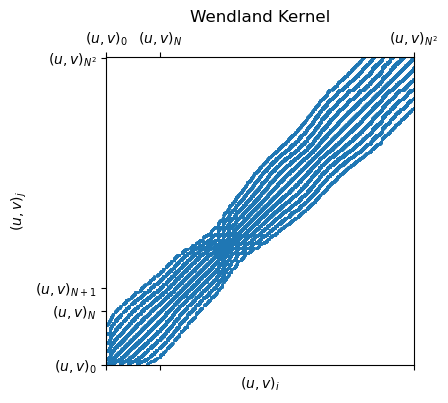

In [22]:
plt.figure(figsize=(4, 4))
plt.spy(WEND, markersize=1)
plt.title("Wendland Kernel")
plt.xlabel("Índice de Columna")
plt.ylabel("Índice de Fila")
plt.xlabel(r'$(u, v)_i$')
plt.ylabel(r'$(u, v)_j$')
plt.xticks(tick_positions_x, tick_labels_x)
plt.yticks(tick_positions_y, tick_labels_y)
plt.xlim(0, 4000)
plt.ylim(0, 4000)
plt.show()

In [23]:
times_wend = []

In [30]:
times_wend = []

In [31]:
frank2d_objects_wend = []

In [32]:
for i in l:
    start_time = time.time()
    params = {'m': params_N80['m'], 'c': params_N80['c'], 'l': i}
    frank2d_wend = Frank2D(N, rout)
    frank2d_wend.fit(uvtable, kernel_type='wend', kernel_params = params, rtol = 1e-10)
    frank2d_objects_wend.append(frank2d_wend)
    end_time = time.time()
    times_wend.append(end_time - start_time)

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -4.572459366888535, 'c': 1.0086866109221515e+24, 'l': 9000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.01  min |  0.84 seconds
        +  Building system = 0.01  min |  0.84 seconds
===>  Solving linear system...
      .... iteration  0 :   actual tol  1.22e+08  versus  1.22e-02
         +  BiCGStab = 0.00  min |  0.00 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.012212677737961322,
 'iterations': 0,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.01  min |  0.86 seconds
--> times building full visibility model = 0.01  min |  0.86 seconds
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -4.572459366888535, 'c': 1.0086866109221515e+24, 'l': 10000.0}
===>  C

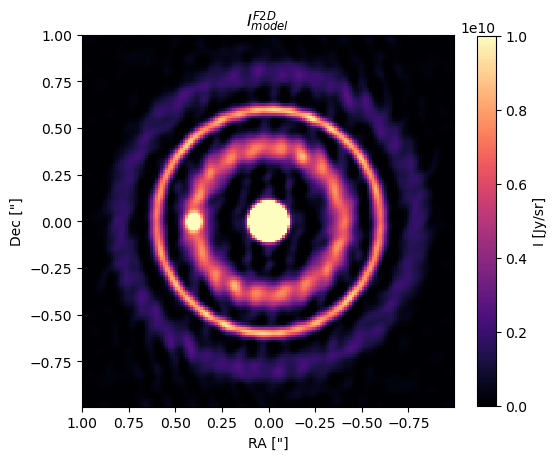

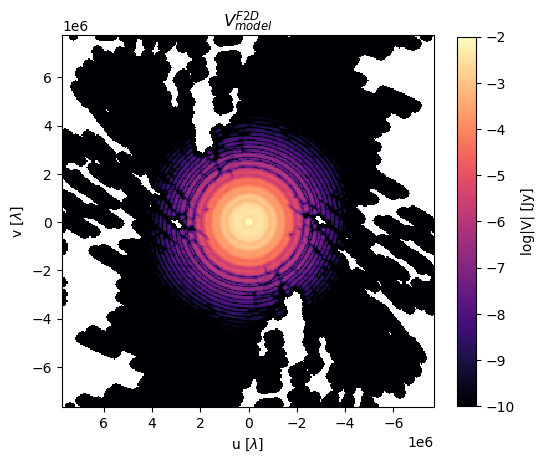

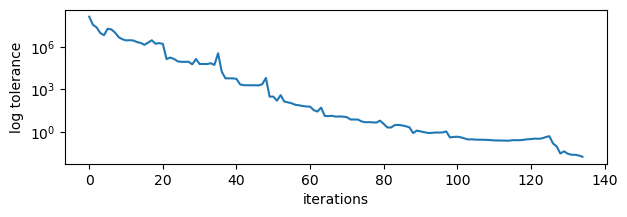

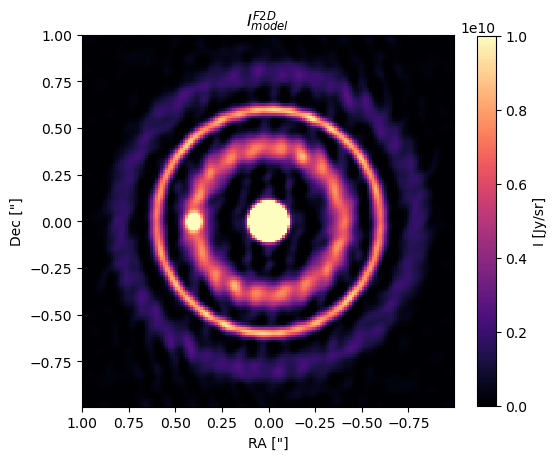

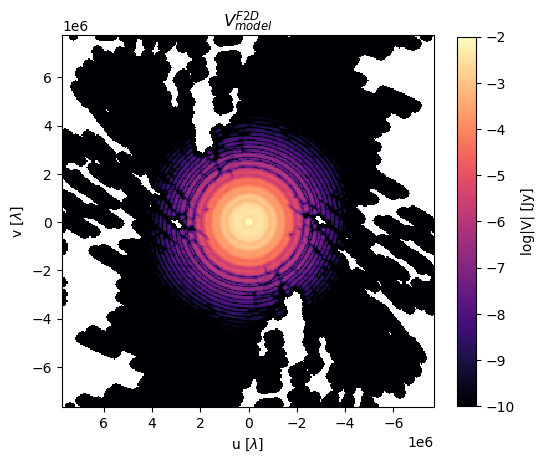

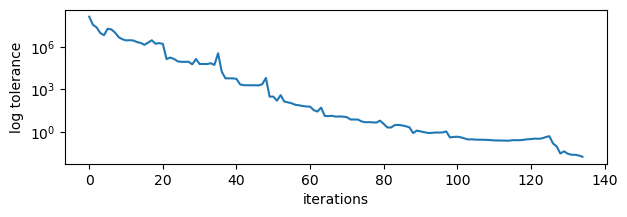

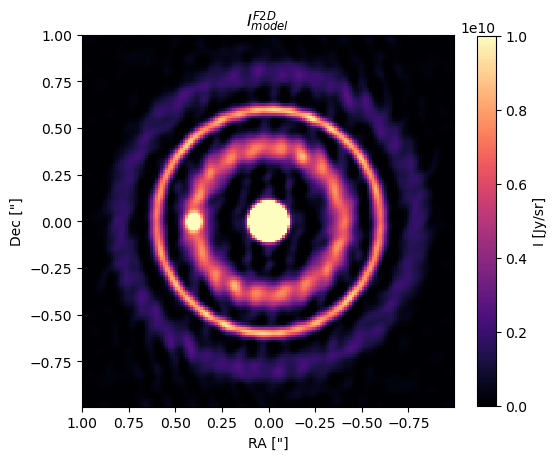

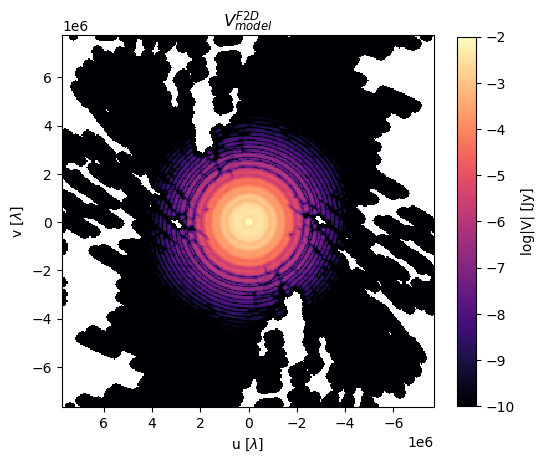

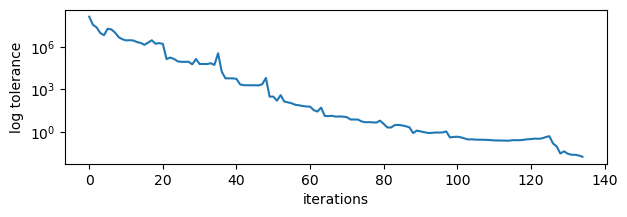

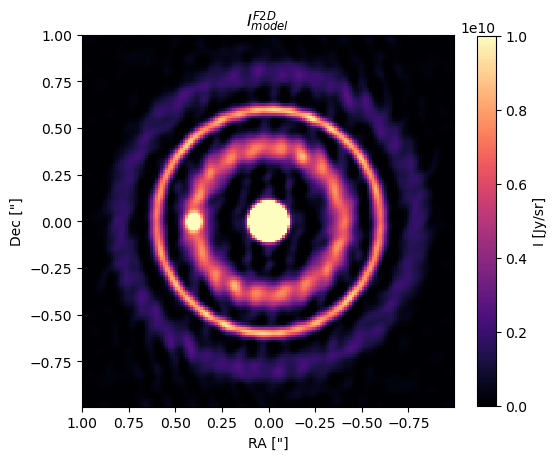

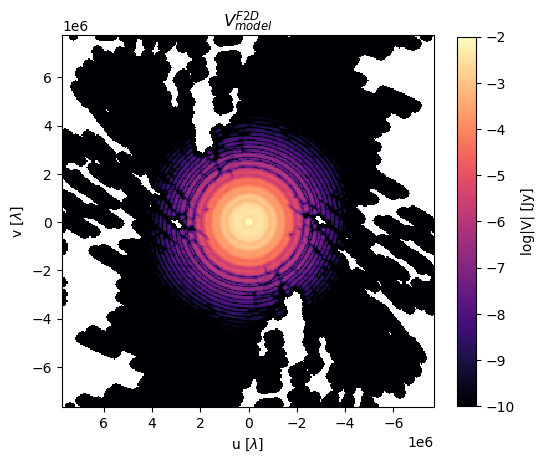

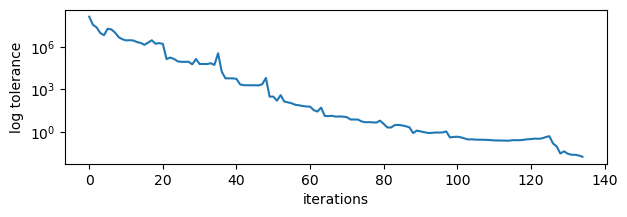

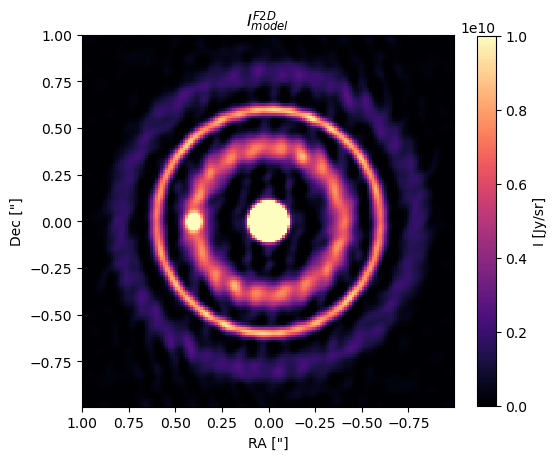

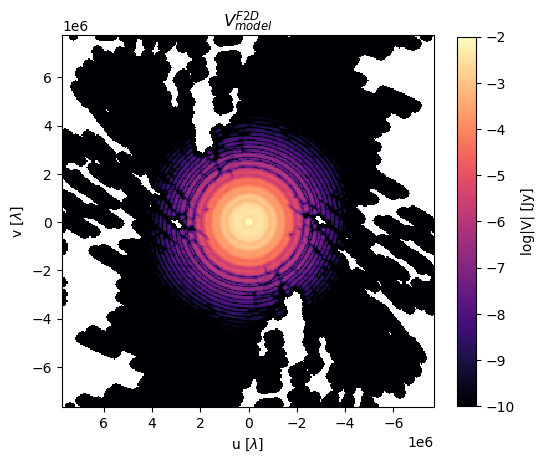

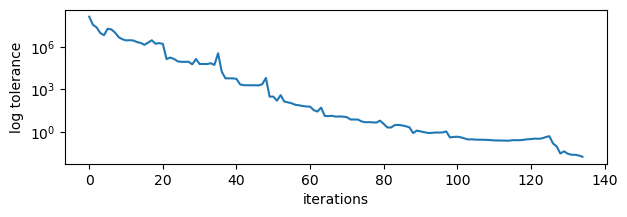

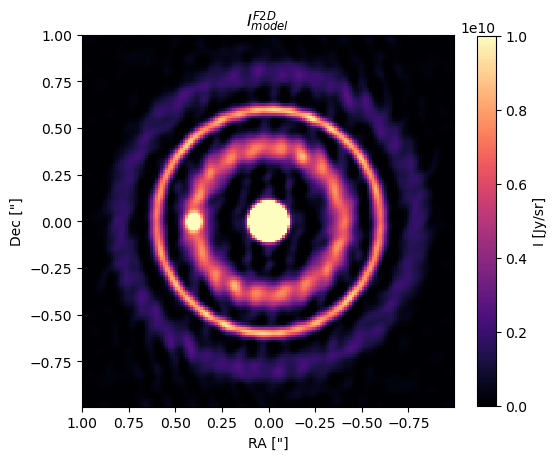

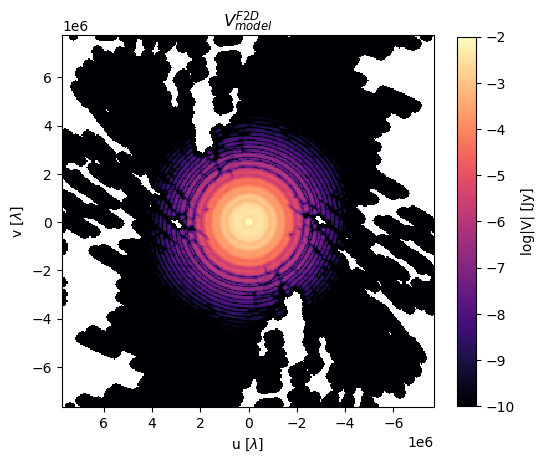

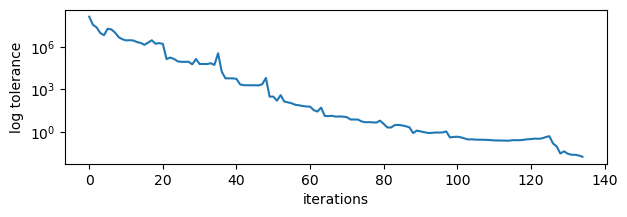

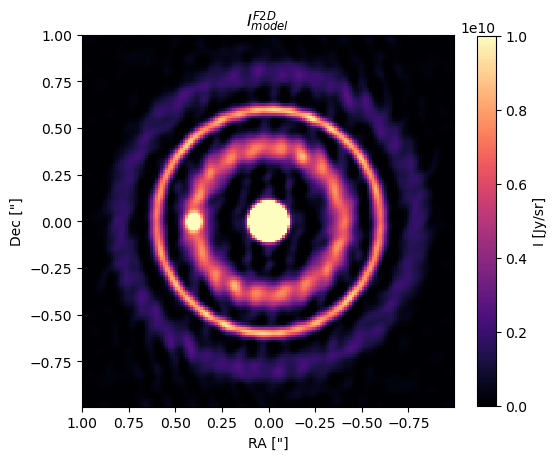

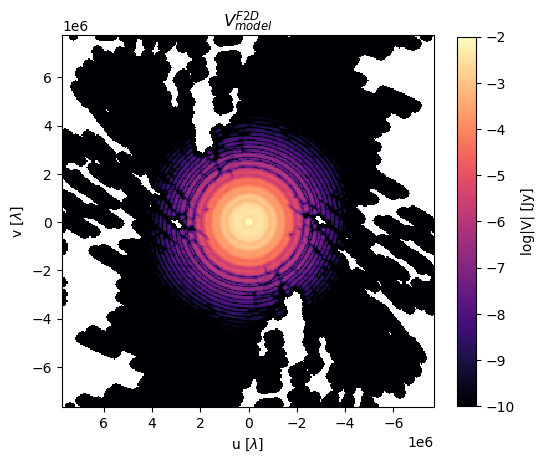

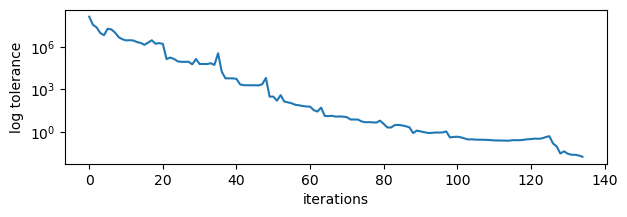

In [33]:
for i in l:
    Plot_wend = Plot(frank2d_wend, geom)
    Plot_wend.intensity(vmax=1e10, gamma = 1, zoom = 2, title = r'$I_{model}^{F2D}$')
    Plot_wend.visibility(fig_size = 6) 
    Plot_wend.cg_tolerance()

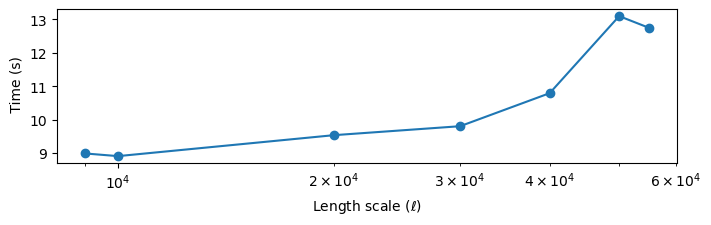

In [58]:
# plot times
plt.figure(figsize=(8,2))
plt.plot(l, times_wend, marker='o')
plt.xscale('log')
plt.xlabel(r'Length scale ($\ell$)')
plt.ylabel(' Time (s)')
plt.show()

### SE Kernel

In [40]:
frank2d_se = Frank2D(N, rout)

In [41]:
frank2d_se.process_vis(uvtable)

===>  Setting gridded data...


In [42]:
frank2d_se.set_kernel(kernel_type = "sqexp", kernel_params = params_N80)
frank2d_se.set_x0(None)

===>  Setting GP Kernel sqexp...
        + Kernel parameters:  {'m': -4.572459366888535, 'c': 1.0086866109221515e+24, 'l': 68720.91547274287}


In [43]:
frank2d_se.set_fit_method()

In [44]:
SE = frank2d_se._kernel.sparse_matrix()

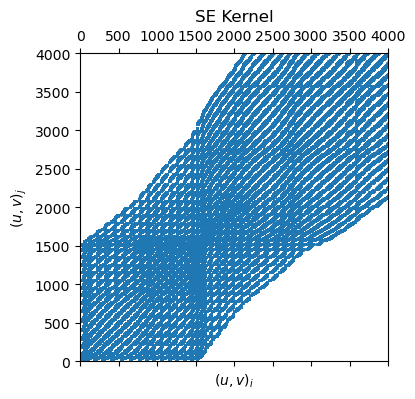

In [45]:
plt.figure(figsize=(4, 4))
plt.spy(SE, markersize=1)
plt.title("SE Kernel")
plt.xlabel(r'$(u, v)_i$')
plt.ylabel(r'$(u, v)_j$')
plt.xlim(0, 4000)
plt.ylim(0, 4000)
plt.show()

In [46]:
frank2d_objects_se = []
times_se = []

In [47]:
for i in l:
    start_time = time.time()
    params = {'m': params_N80['m'], 'c': params_N80['c'], 'l': i}
    frank2d_se = Frank2D(N, rout)
    frank2d_se.fit(
                    data = uvtable,
                    kernel_params = params , rtol = 1e-10, 
                    kernel_type = 'sqexp'
                )
    frank2d_objects_se.append(frank2d_se)
    end_time = time.time()
    times_se.append(end_time - start_time)
    

===>  Setting gridded data...
===>  Setting GP Kernel sqexp...
        + Kernel parameters:  {'m': -4.572459366888535, 'c': 1.0086866109221515e+24, 'l': 9000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.01  min |  0.80 seconds
        +  Building system = 0.01  min |  0.81 seconds
===>  Solving linear system...
      .... iteration  0 :   actual tol  1.22e+08  versus  1.22e-02
         +  BiCGStab = 0.00  min |  0.01 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of r',
 'final_tol': 0.012212677737961322,
 'iterations': 1,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.01  min |  0.33 seconds
--> times building full visibility model = 0.01  min |  0.34 seconds
===>  Setting gridded data...
===>  Setting GP Kernel sqexp...
        + Kernel parameters:  {'m': -4.572459366888535, 'c': 1.0086866109221515e+24, 'l': 10000.0}
===> 

KeyboardInterrupt: 

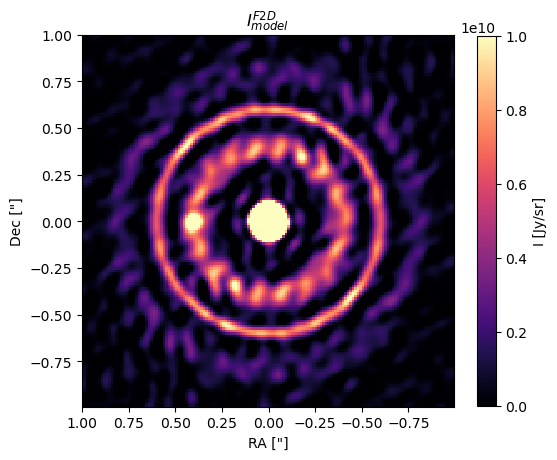

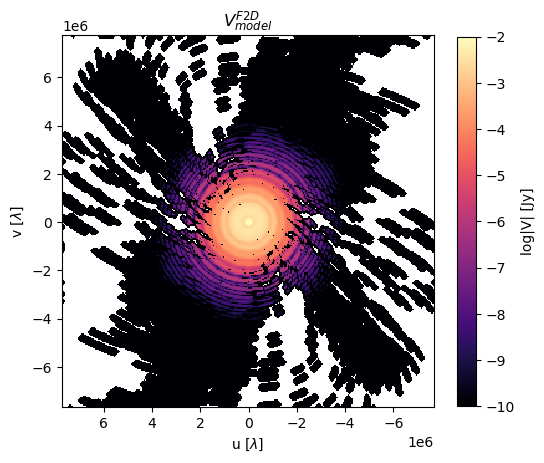

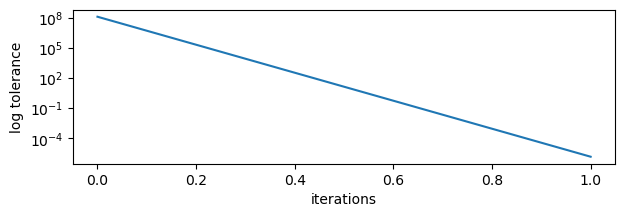

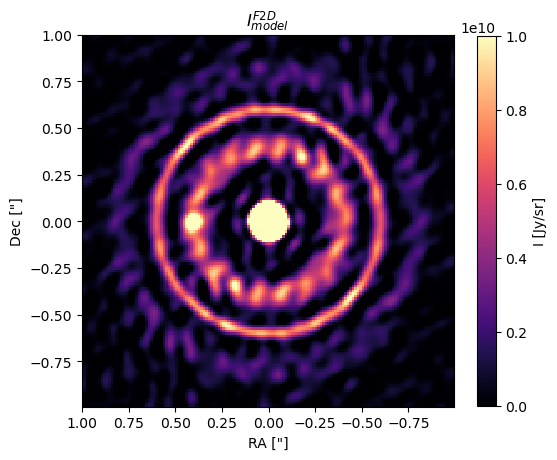

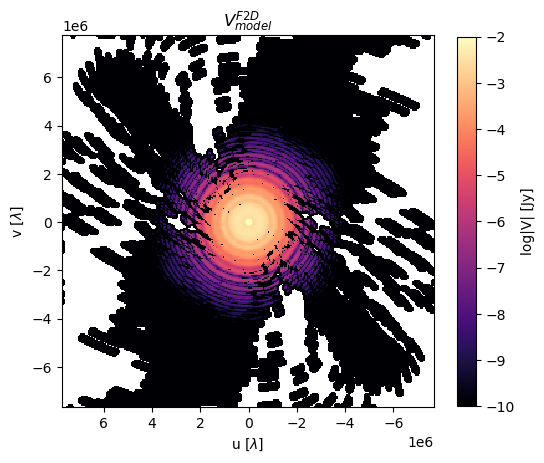

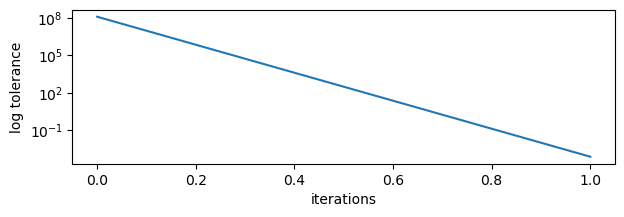

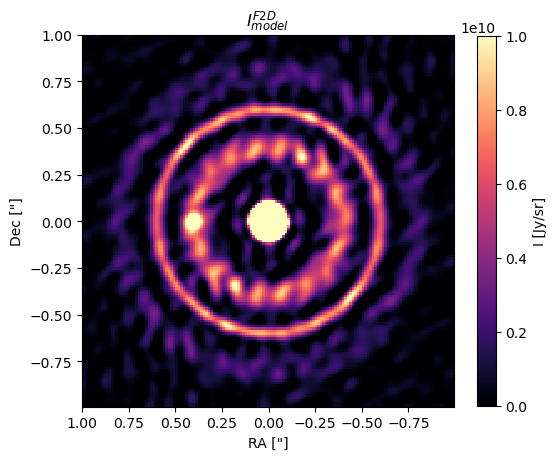

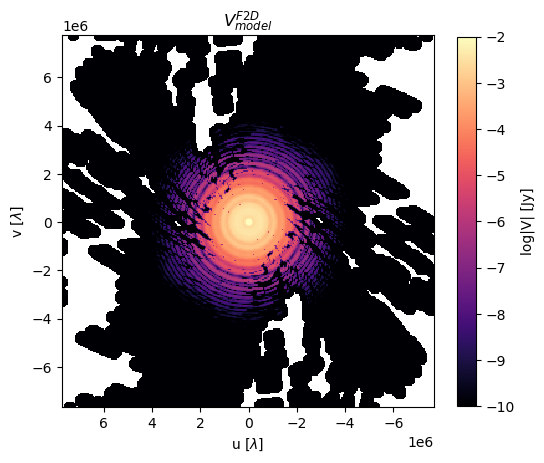

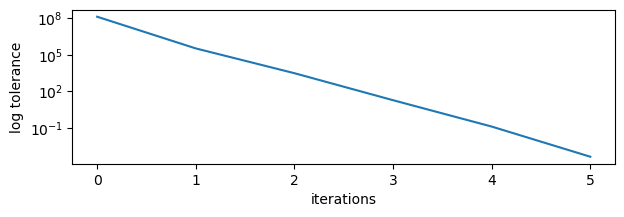

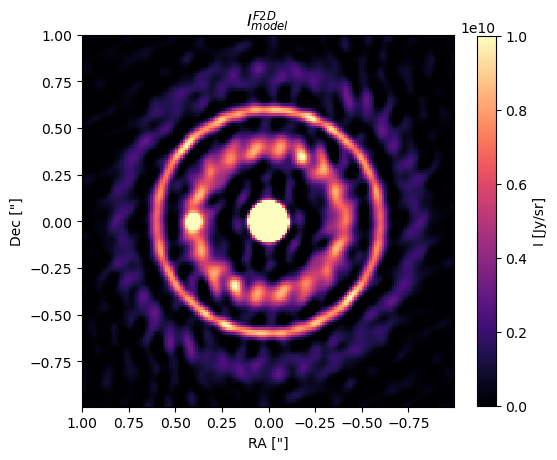

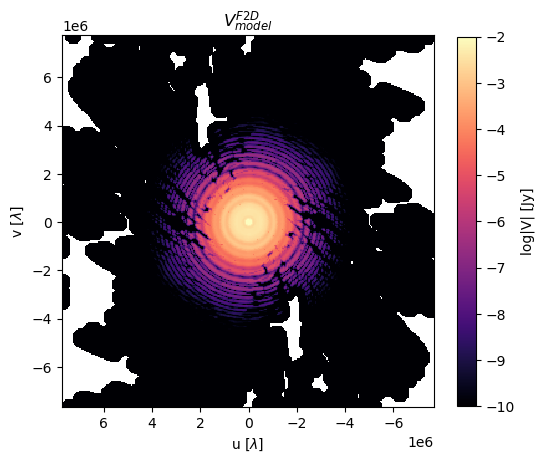

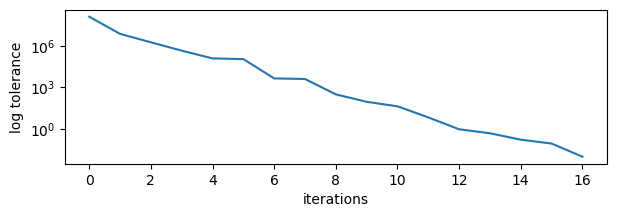

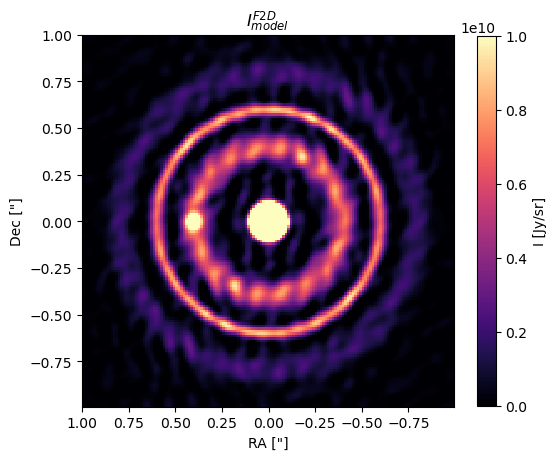

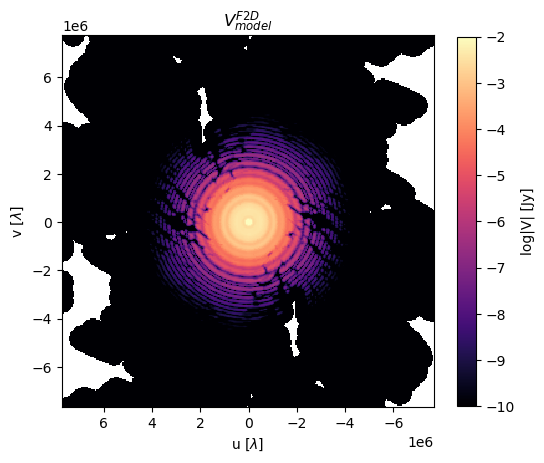

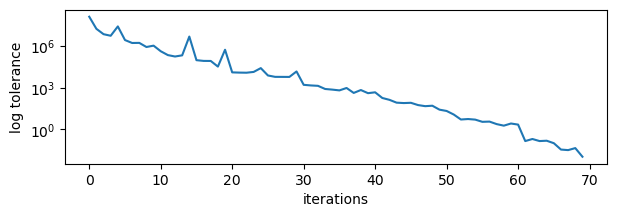

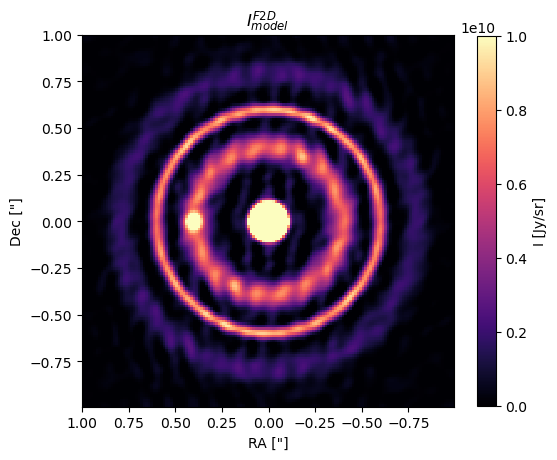

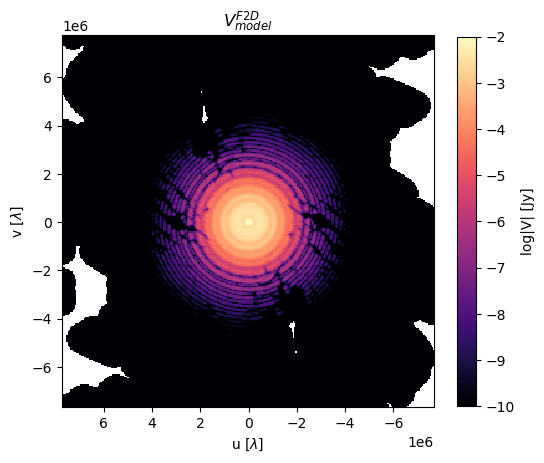

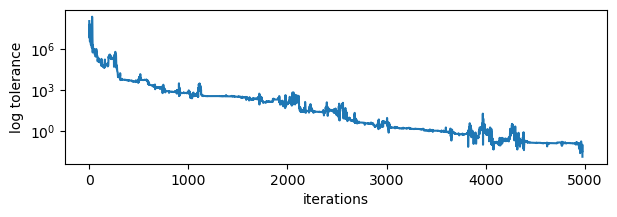

In [51]:
for i in frank2d_objects_se:
    Plot_se = Plot(i, geom)
    Plot_se.intensity(vmax=1e10, gamma = 1, zoom = 2, title = r'$I_{model}^{F2D}$')
    Plot_se.visibility(fig_size = 6) 
    Plot_se.cg_tolerance()

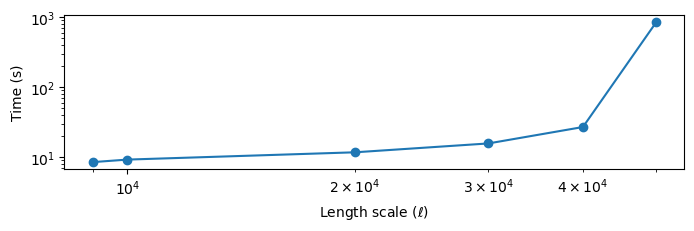

In [57]:
# plot times
plt.figure(figsize=(8,2))
plt.plot(l[:-1], times_se, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Length scale ($\ell$)')
plt.ylabel( 'Time (s)')
plt.show()